In [34]:
# imports and such
from pathlib import Path
from utils import load_plastchem, extract_feature_vecs, calculate_mfps
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE
from rdkit.Chem import AllChem
import pandas as pd
from sklearn.cluster import KMeans
from pprint import pprint
from sklearn.preprocessing import StandardScaler

In [35]:
plast_chem, pcc = load_plastchem(Path.cwd() / "data" / "plastchem_db_v1.0.tsv")
hazard_cols = [
        'Hazard_information_Carcinogenic', 'Hazard_information_Mutagenic', 'Hazard_information_Reproduction', 'Hazard_information_CMR', 'Hazard_information_STOT',
        'Hazard_information_EDC', 'Hazard_information_Aquatic_toxicity', 'Hazard_information_PBT', 'Hazard_information_vPvB', 'Hazard_information_PMT', 'Hazard_information_vPvM'
    ]

In [36]:
print(pcc)

Index(['Identifiers_plastchem_ID', 'Identifiers_cas', 'Identifiers_cas_fixed',
       'Identifiers_identified_by', 'Identifiers_pubchem_cid',
       'Identifiers_pubchem_name', 'Identifiers_iupac_name',
       'Properties_molecular_formula', 'Properties_molecular_weight',
       'Properties_canonical_smiles',
       ...
       'Information_sources_in_fccmigex', 'Information_sources_in_litchem',
       'Information_sources_in_plasticmap',
       'Information_sources_original_name_aurisano',
       'Information_sources_original_name_cpp',
       'Information_sources_original_name_echa',
       'Information_sources_original_name_fcc',
       'Information_sources_original_name_fccmigex',
       'Information_sources_original_name_litchem',
       'Information_sources_original_name_plasticmap'],
      dtype='str', length=230)


### ToDo
- calculate fingerprints and then see if those help with the PCA
- find some way to get words?? into PCA → put as numeric label maybe (way to group them)

In [37]:
# exclude NAs
plast_chem_hazard = plast_chem[plast_chem[hazard_cols].notna().any(axis=1)]
plast_chem_hazard = plast_chem_hazard.where(plast_chem_hazard['Hazard_information_Toxicity_score'] != 0.25)

# include NAs → test for sparsity algo
#plast_chem_hazard = plast_chem[plast_chem[hazard_cols].notna().any(axis=1)]
#plast_chem_hazard = plast_chem.where(plast_chem['Hazard_information_Toxicity_score'] != 0.25)

print(plast_chem_hazard['Hazard_information_Hazard_score'].value_counts())

# fingerprints
fps = calculate_mfps(plast_chem_hazard, 'Properties_canonical_smiles')

mask = [fp is not None for fp in fps]
plast_chem_hazard_c = plast_chem_hazard[mask].copy()
fps = [fp for fp in fps if fp is not None]

X = np.vstack(fps)

Hazard_information_Hazard_score
2.0    3049
0.5    1188
1.0    1041
0.0     161
Name: count, dtype: int64


[13:41:19] WARNING: not removing hydrogen atom without neighbors
[13:41:19] WARNING: not removing hydrogen atom without neighbors
[13:41:19] WARNING: not removing hydrogen atom without neighbors
[13:41:19] WARNING: not removing hydrogen atom without neighbors
[13:41:19] WARNING: not removing hydrogen atom without neighbors
[13:41:19] WARNING: not removing hydrogen atom without neighbors
[13:41:19] WARNING: not removing hydrogen atom without neighbors
[13:41:19] WARNING: not removing hydrogen atom without neighbors
[13:41:19] WARNING: not removing hydrogen atom without neighbors
[13:41:19] WARNING: not removing hydrogen atom without neighbors
[13:41:19] WARNING: not removing hydrogen atom without neighbors
[13:41:19] WARNING: not removing hydrogen atom without neighbors
[13:41:19] WARNING: not removing hydrogen atom without neighbors
[13:41:19] WARNING: not removing hydrogen atom without neighbors
[13:41:19] WARNING: not removing hydrogen atom without neighbors
[13:41:19] Explicit valen

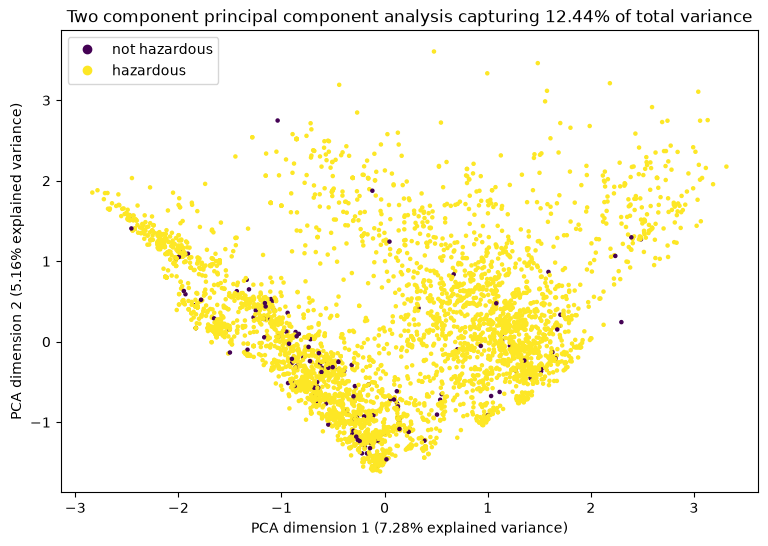

In [70]:
# cluster data on all information → extract feature vectures by PCA
# some of the data is discrete, other continous → what do i do

# fv, explained = extract_feature_vecs(plast_chem, n=2, [('Properties_molecular_weight'), ('Properties_exact_mass'), ('Properties_monoisotopic_mass'),
#                                    ('Properties_tpsa'), ('Properties_complexity')])

#x_scaled = StandardScaler().fit_transform(X)
y = plast_chem_hazard_c['Hazard_information_Hazard_score'].replace(0.5,1).replace(2,1).replace(3,1)
X = X.copy()
fv, explained = extract_feature_vecs(X, n=2)

sum_ex = sum(explained)
fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot()
scatter = ax.scatter(fv[:,0], fv[:,1], s=5, c=y)
ax.set_xlabel(f'PCA dimension 1 ({np.round(explained[0]*100,2)}% explained variance)')
ax.set_ylabel(f'PCA dimension 2 ({np.round(explained[1]*100,2)}% explained variance)')
ax.set_title(f"Two component principal component analysis capturing {np.round(sum_ex*100,2)}% of total variance")
handles, _ = scatter.legend_elements()
ax.legend(handles=handles, labels=["not hazardous", "hazardous"])
plt.savefig(Path.cwd() /"pca.svg")

# this kind of says that fingerprints are too high dimensional to just be represented as 2D PCA
# explains only 12% variance in total
# and also they do not cluster into the hazard scores based on their fingerprints at all (yay)

In [4]:
calculate_mfps(plast_chem, 'Properties_canonical_smiles')

[15:18:39] WARNING: not removing hydrogen atom without neighbors
[15:18:39] WARNING: not removing hydrogen atom without neighbors
[15:18:39] WARNING: not removing hydrogen atom without neighbors
[15:18:39] WARNING: not removing hydrogen atom without neighbors
[15:18:39] WARNING: not removing hydrogen atom without neighbors
[15:18:39] WARNING: not removing hydrogen atom without neighbors
[15:18:39] WARNING: not removing hydrogen atom without neighbors
[15:18:39] WARNING: not removing hydrogen atom without neighbors
[15:18:39] WARNING: not removing hydrogen atom without neighbors
[15:18:39] WARNING: not removing hydrogen atom without neighbors
[15:18:39] WARNING: not removing hydrogen atom without neighbors
[15:18:39] WARNING: not removing hydrogen atom without neighbors
[15:18:39] Explicit valence for atom # 1 Br, 2, is greater than permitted
[15:18:39] WARNING: not removing hydrogen atom without neighbors
[15:18:39] WARNING: not removing hydrogen atom without neighbors
[15:18:39] WARNI

[array([0, 0, 0, ..., 0, 0, 0], shape=(2048,)),
 array([0, 0, 0, ..., 0, 0, 0], shape=(2048,)),
 array([0, 0, 0, ..., 0, 0, 0], shape=(2048,)),
 array([0, 0, 0, ..., 0, 0, 0], shape=(2048,)),
 array([0, 0, 0, ..., 0, 0, 0], shape=(2048,)),
 array([0, 0, 0, ..., 0, 0, 0], shape=(2048,)),
 array([0, 0, 0, ..., 0, 0, 0], shape=(2048,)),
 array([0, 0, 0, ..., 0, 0, 0], shape=(2048,)),
 array([0, 0, 0, ..., 0, 0, 0], shape=(2048,)),
 array([0, 0, 0, ..., 0, 0, 0], shape=(2048,)),
 array([0, 0, 0, ..., 0, 0, 0], shape=(2048,)),
 array([0, 0, 0, ..., 0, 0, 0], shape=(2048,)),
 array([0, 0, 0, ..., 0, 0, 0], shape=(2048,)),
 array([0, 0, 0, ..., 0, 0, 0], shape=(2048,)),
 array([0, 0, 1, ..., 0, 0, 0], shape=(2048,)),
 array([0, 0, 0, ..., 0, 0, 0], shape=(2048,)),
 array([0, 0, 0, ..., 0, 0, 0], shape=(2048,)),
 array([0, 0, 0, ..., 0, 0, 0], shape=(2048,)),
 array([0, 0, 0, ..., 0, 0, 0], shape=(2048,)),
 array([0, 0, 1, ..., 0, 0, 0], shape=(2048,)),
 array([0, 0, 0, ..., 0, 0, 0], shape=(2

might be useful for later, first classify data into hazardous etc → this many are without hazard information

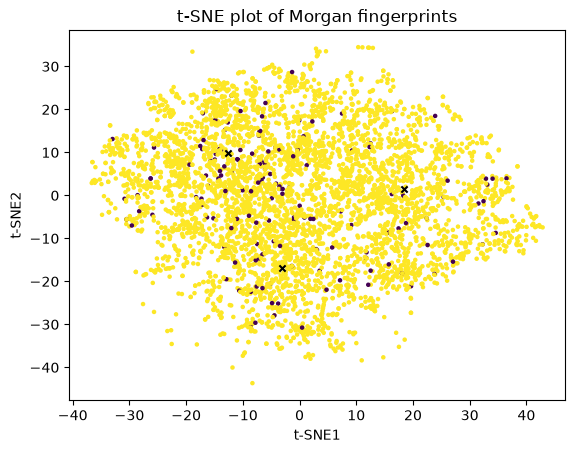

In [ ]:

# # (n_molecules, n_bits)
tsne = TSNE(n_components=3, random_state=1)
reduced_data = tsne.fit_transform(X)

kmeans = KMeans(n_clusters=3)
kmeans.fit(reduced_data)

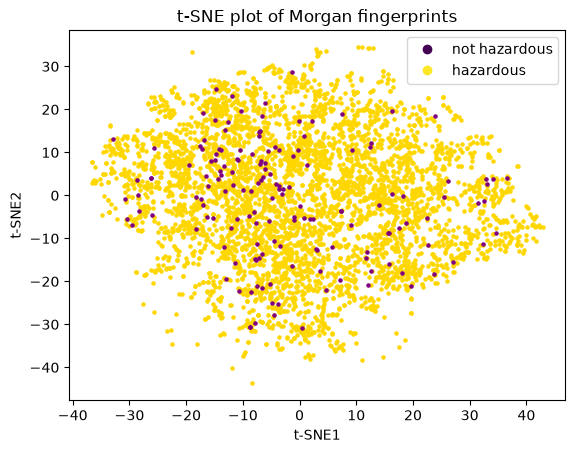

In [65]:
# Plot scatter plot of reduced data with cluster labels
plt.scatter(reduced_data[y==1, 0], reduced_data[y==1, 1], c="gold", s=5, label="hazardous")
plt.scatter(reduced_data[y==0, 0], reduced_data[y==0, 1], c="purple", s=5, label="not hazardous")
plt.xlabel('t-SNE1')
plt.ylabel('t-SNE2')
plt.title('t-SNE plot of Morgan fingerprints')
handles, _ = scatter.legend_elements()
plt.legend(handles=handles, labels=["not hazardous", "hazardous"])
plt.show()

In [6]:
# plan: extract feature vecs on PCA, then cluster based on commodity plastics ??
print(plast_chem['Hazard_information_Hazard_score'].value_counts(dropna=False).head(10))

Hazard_information_Hazard_score
NaN     10726
2.00     3166
0.50     1191
1.00     1051
0.00      161
0.25       28
Name: count, dtype: int64


### hazard classes plots

Hazard_information_Carcinogenic        1276
Hazard_information_Mutagenic           1004
Hazard_information_Reproduction        1301
Hazard_information_CMR                 2217
Hazard_information_STOT                1799
Hazard_information_EDC                  121
Hazard_information_Aquatic_toxicity    4587
Hazard_information_PBT                  248
Hazard_information_vPvB                 224
Hazard_information_PMT                  129
Hazard_information_vPvM                 130
dtype: int64


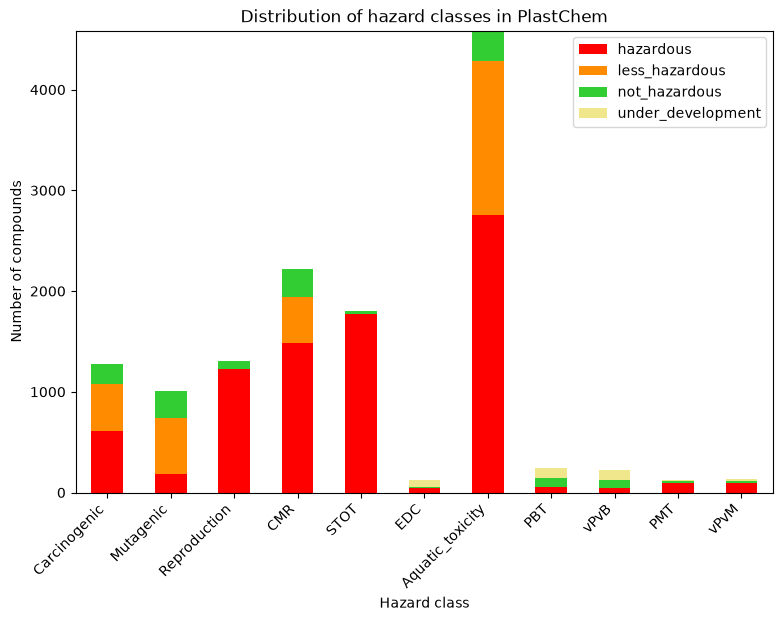

In [10]:
# visualization for distribution of hazard classes

hazard_cols = [
        'Hazard_information_Carcinogenic', 'Hazard_information_Mutagenic', 'Hazard_information_Reproduction', 'Hazard_information_CMR', 'Hazard_information_STOT', 'Hazard_information_EDC', 'Hazard_information_Aquatic_toxicity', 'Hazard_information_PBT', 'Hazard_information_vPvB', 'Hazard_information_PMT', 'Hazard_information_vPvM'
    ]

plastics = [
    'PET', 'PE', 'PP', 'PVC', 'PA', 'PS', 'Rubber', 'PUR', 'ABS', 'PC'
]


def hazard_plot(plast_chem, title):
    """
    Plots the hazard classes per polymer type
    """

    # for col in hazard_cols:
    #     print(col)
    #     print(plast_chem[col].value_counts(dropna=False).head(10))
    #     print("----")

    # 16325
    summary = pd.DataFrame({
        "hazardous": plast_chem[hazard_cols].isin([1, 2]).sum(),
        "less_hazardous": (plast_chem[hazard_cols] == 0.5).sum(),
        "not_hazardous": (plast_chem[hazard_cols] == 0).sum(),
        "under_development": (plast_chem[hazard_cols] == 0.25).sum(),
        #"not_classified": plast_chem[hazard_cols].isna().sum()
    })

    colors = ["red", "darkorange", "limegreen", "khaki", "gainsboro"]

    # sanity check
    print(summary.sum(axis=1))

    summary.index = summary.index.str.replace("Hazard_information_", "")
    ax = summary.plot(
        kind="bar",
        stacked=True,
        figsize=(9,6),
        color=colors
    )

    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

    ax.set_ylabel("Number of compounds")
    ax.set_xlabel("Hazard class")
    ax.set_title(title)

    return ax
    # plt.tight_layout()
    # plt.show()

plt.show(hazard_plot(plast_chem, "Distribution of hazard classes in PlastChem"))
# important: one compound can have any number of hazard classes

       index Identifiers_plastchem_ID Identifiers_cas Identifiers_cas_fixed  \
0          3                        3        100-10-7             '100-10-7   
1          4                        4        100-17-4             '100-17-4   
2          5                        5        100-20-9             '100-20-9   
3          6                        6        100-21-0             '100-21-0   
4          7                        7        100-37-8             '100-37-8   
...      ...                      ...             ...                   ...   
16302  16305                    16305       1330-80-9            '1330-80-9   
16305  16308                    16308      25322-17-2           '25322-17-2   
16307  16310                    16310      26762-93-6           '26762-93-6   
16309  16312                    16312      28106-30-1           '28106-30-1   
16316  16319                    16319      68515-47-9           '68515-47-9   

      Identifiers_identified_by Identifiers_pubchem

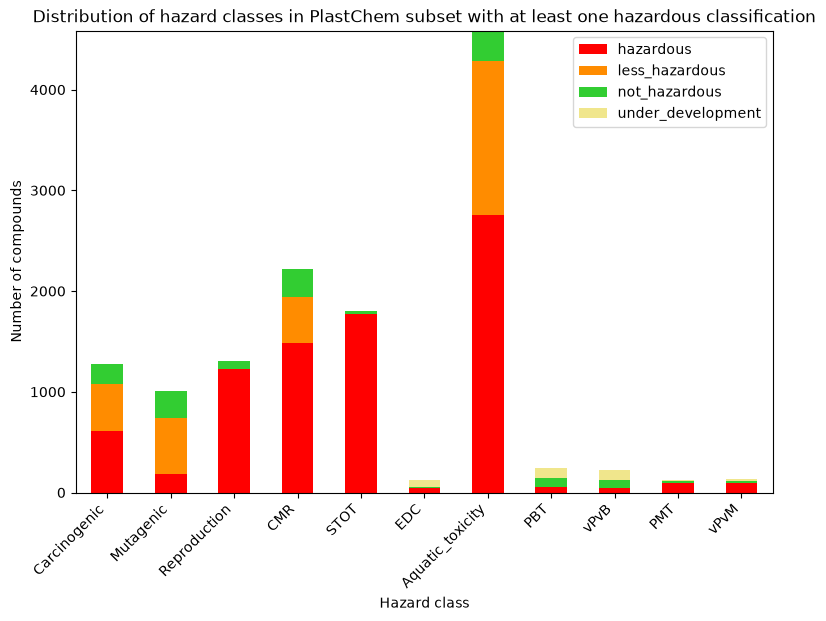

In [11]:
# get only ones that have at least one hazard classification
plast_chem_hazard = plast_chem[plast_chem[hazard_cols].notna().any(axis=1)]
print(plast_chem_hazard)
plt.show(hazard_plot(plast_chem_hazard, "Distribution of hazard classes in PlastChem subset with at least one hazardous classification"))
# this will be what xgboost is trained and evaluated on

4        1.00
7        0.25
8        0.25
16       0.25
17       0.50
         ... 
16241    0.50
16261    0.25
16262    0.50
16290    0.50
16316    0.50
Name: Commodity_plastics_PUR, Length: 628, dtype: float64
Hazard_information_Carcinogenic        216
Hazard_information_Mutagenic           183
Hazard_information_Reproduction        233
Hazard_information_CMR                 352
Hazard_information_STOT                305
Hazard_information_EDC                  42
Hazard_information_Aquatic_toxicity    523
Hazard_information_PBT                  88
Hazard_information_vPvB                 78
Hazard_information_PMT                  30
Hazard_information_vPvM                 30
dtype: int64


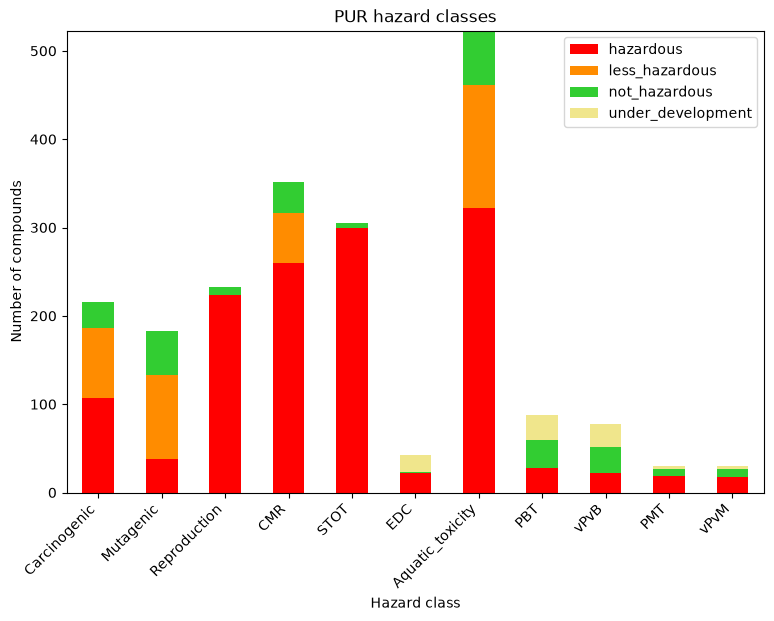

In [12]:
# get PUR ones from that
PUR_hazard = plast_chem_hazard.apply(
    pd.to_numeric,
    errors='coerce'
)
PUR_only = PUR_hazard[PUR_hazard["Commodity_plastics_PUR"].notna()]
print(PUR_only['Commodity_plastics_PUR'])
plt.show(hazard_plot(PUR_only, 'PUR hazard classes'))

### hazard plots per polymer type

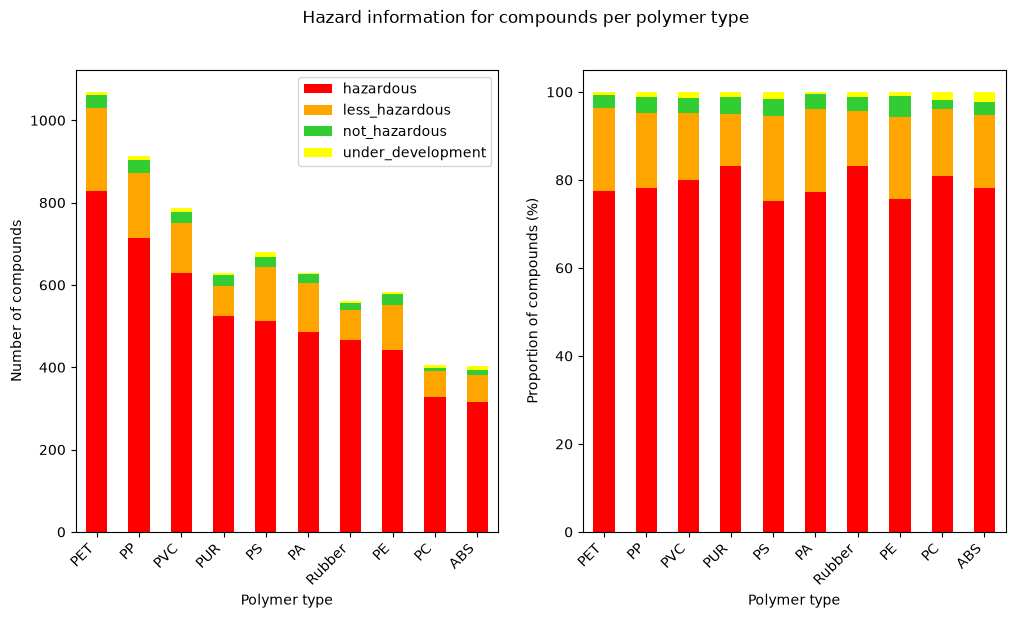

In [13]:
hazard_cols = [
        'Hazard_information_Carcinogenic', 'Hazard_information_Mutagenic', 'Hazard_information_Reproduction', 'Hazard_information_CMR',
        'Hazard_information_STOT', 'Hazard_information_EDC', 'Hazard_information_Aquatic_toxicity', 'Hazard_information_PBT', 
        'Hazard_information_vPvB', 'Hazard_information_PMT', 'Hazard_information_vPvM'
    ]

plastics = [
    '_PET', '_PE', '_PP', '_PVC', '_PA', '_PS', '_Rubber', '_PUR', '_ABS', '_PC'
]
col_plastics = [col for col in plast_chem.columns if col.endswith(tuple([polymer for polymer in plastics]))]

def polymer_plot(plast_chem, title):
    """
    Plots the hazard classes per polymer type
    """

    # for col in hazard_cols:
    #     print(col)
    #     print(plast_chem[col].value_counts(dropna=False).head(10))
    #     print("----")
    rows = []

    # 16325
    for col in col_plastics:
        subset_pol = plast_chem[plast_chem[col].notna()]
        hazard = subset_pol['Hazard_information_Hazard_score']

        rows.append({
            "polymer": col.replace("Commodity_plastics_", "").replace("Elastomers_", "").replace("Specialty_plastic_", ""),
            "hazardous": hazard.isin([1, 2]).sum(),
            "less_hazardous": (hazard == 0.5).sum(),
            "not_hazardous": (hazard == 0).sum(),
            "under_development": (hazard == 0.25).sum(),
            #"not_classified": hazard.isna().sum()
        })

    polymer_hazards = pd.DataFrame(rows)
    polymer_hazards.sort_values(by='hazardous', inplace=True, ascending=False)

    colors = [ "red", "orange", "limegreen", "yellow", "gainsboro"]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6))

    ax1 = polymer_hazards.set_index("polymer").plot(
        ax=ax1,
        kind="bar",
        stacked=True,
        color=colors
    )

    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")

    ax1.set_ylabel("Number of compounds")
    ax1.set_xlabel("Polymer type")

    polymer_percent = (
        polymer_hazards
        .set_index("polymer")
        .div(
            polymer_hazards.set_index("polymer").sum(axis=1),
            axis=0
        ).multiply(100)
    )

    ax2 = polymer_percent.plot(
        ax=ax2,
        kind="bar",
        stacked=True,
        color=colors
    )

    ax2.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")

    ax2.set_ylabel("Proportion of compounds (%)")
    ax2.set_xlabel("Polymer type")
    ax2.legend_ = None
    fig.suptitle(title)

    return fig

plt.show(polymer_plot(plast_chem, "Hazard information for compounds per polymer type"))

Hazard_information_Carcinogenic        216
Hazard_information_Mutagenic           183
Hazard_information_Reproduction        233
Hazard_information_CMR                 352
Hazard_information_STOT                305
Hazard_information_EDC                  42
Hazard_information_Aquatic_toxicity    523
Hazard_information_PBT                  88
Hazard_information_vPvB                 78
Hazard_information_PMT                  30
Hazard_information_vPvM                 30
dtype: int64


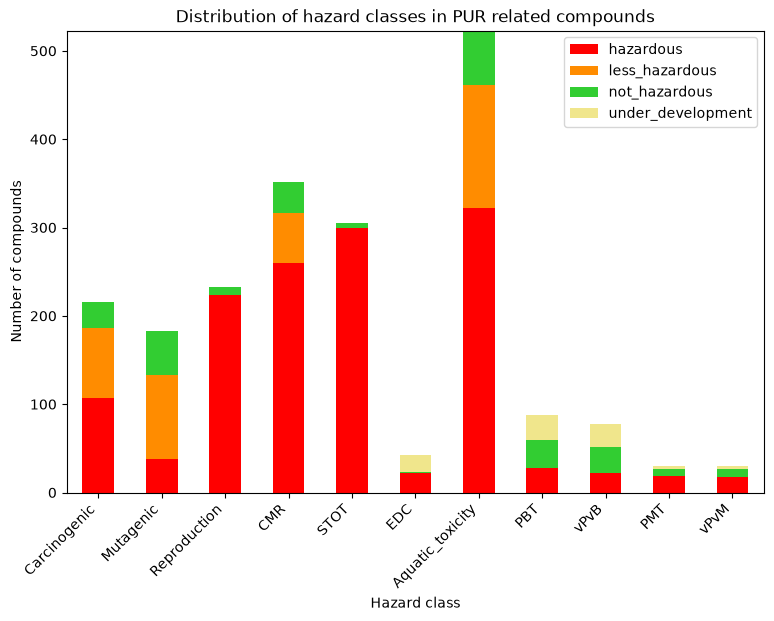

In [14]:
# polyurethan hazard distribution
PUR_only = plast_chem[plast_chem['Commodity_plastics_PUR'].notna()]
plt.show(hazard_plot(PUR_only, 'Distribution of hazard classes in PUR related compounds'))

In [ ]:
# idea → scatter plot with all known toxicities and grey out the unknown ones?

In [ ]:
# extract all PU ones from that